# 07. Temporal readout diagnostic: does 384-d pooling discard recoverable gait timing?

**Direction supported:** *"Readout or Representation?"* — the capacity-matched temporal probing and spectral audit
described in `docs/neurips-brain-body.md` (Direction B). This is the **backup paper** for the
NeurIPS 2026 BrainBodyFM workshop, and the *fastest* decisive experiment in the whole roadmap:
it uses only **frozen checkpoints** and **cached poses**, so it completes in minutes on a laptop.

## The motivating fact (exact, not speculative)

The deployed downstream vector concatenates four 96-d blocks computed from the frozen EMA target encoder:

* global mean over all 528 valid joint-time tokens;
* global standard deviation;
* mean over the 12 authorized neurologic landmarks;
* standard deviation over those 12 landmarks.

Mean and standard deviation **do not change when the 16 time patches are permuted**. The deployed
readout therefore discards temporal order **by construction**. That means every conclusion of the form
"the S-JEPA representation lost temporal gait information" is currently uninterpretable: the loss could
be in the *readout* (pooling) or in the *encoder* (the tokens themselves never encoded time).

This notebook settles that question with a controlled experiment that holds the **same frozen token
tensor** fixed and varies only the readout, under **strict source-video-grouped** splits:

| Lane | Readout | 384-d? | Order-sensitive? | Learned pooling? |
|---|---|---|---|---|
| A | deployed mean/std pooling | yes | no | no |
| B | global mean/std + **signed first temporal moment** | yes | **yes** | no |
| C | **segment-level** mean/std over 4 coarse time bins | yes | coarse | no |
| D | per-patch tokens + **learned attention pool** + stats | yes | **yes** | yes (96 params) |

All four lanes consume the *identical* token tensor `[N, 16, 33, 96]`. If Lane B (zero extra trainable
parameters) beats Lane A on pre-registered timing targets, pooling — not the encoder — was the
bottleneck. If it does not, a spectral audit localizes the loss inside the encoder.

## Claim discipline (unchanged from notebooks 00–06)

* The **source video** is the independent unit; every regression below uses `GroupKFold` on `video_id`.
* The frozen encoder is **transductive**: it saw every evaluation row. This notebook measures *readout
  recoverability inside the known corpus*, not generalization to unseen people or clinics.
* Folder labels are dataset annotations, not diagnoses. This is a representation study, not a clinical
  validation.
* The canonical result set belongs to fingerprint `d0acc262...` (checkpoint file SHA-256 `6e67fc5c...`).

**Research use only.** Nothing here diagnoses a person or validates a clinical device.


In [1]:
from pathlib import Path
import os
import sys
import math

# --- Robust project-layout resolution -------------------------------------
NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "work").exists() and os.getenv("ALEXPOSE_ROOT"):
    NOTEBOOK_DIR = (
        Path(os.environ["ALEXPOSE_ROOT"]).expanduser().resolve()
        / "experiments" / "sjepa" / "gavd5-drift"
    )
if not (NOTEBOOK_DIR / "work").exists():
    raise FileNotFoundError(
        f"Cannot locate the gavd5-drift project folder from {NOTEBOOK_DIR}. "
        "Run this notebook from experiments/sjepa/gavd5-drift or set ALEXPOSE_ROOT."
    )

MODE = os.environ.setdefault("GAVD_MODE", "real").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print("SMOKE MODE: hand-authored motions test code paths only.")

CACHE_DIR = Path(
    os.environ.setdefault("GAVD_CACHE_DIR", str(NOTEBOOK_DIR / "cache"))
).expanduser()
ARTIFACT_ROOT = Path(
    os.environ.setdefault(
        "GAVD_ARTIFACT_DIR", str(NOTEBOOK_DIR / "work" / "artifacts")
    )
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"
AUGMENTED_POSE_DIR = ARTIFACT_DIR / "poses_augmented"
AUGMENTED_REPORT = ARTIFACT_DIR / "augmented_pose_extraction_report.csv"

INCLUDE_AUGMENTED_NORMAL = os.environ.setdefault(
    "SJEPA_INCLUDE_AUGMENTED_NORMAL", "0"
).strip().lower() in {"1", "true", "yes", "on"}

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd

print(f"mode: {MODE}")
print(f"artifacts: {ARTIFACT_DIR}")
print("augmentation-normal cohort: "
      + ("ENABLED (additive)" if INCLUDE_AUGMENTED_NORMAL else "disabled"))


mode: real
artifacts: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real
augmentation-normal cohort: disabled


In [2]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


In [3]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


In [4]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    # Fill only short internal gaps and preserve the original validity mask.
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(sequence, frames=64, visibility_threshold=0.45, max_gap=4):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [5]:
def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            required = {
                "sequence", "sequence_id", "video_id", "condition",
                "frame_numbers", "crop_bounds", "fps", "source_csv",
                "source_video", "pose_model", "pose_model_sha256",
                "extraction_version",
            }
            missing = required.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored_condition = str(data["condition"].item())
            if stored_condition != condition:
                raise ValueError(
                    f"Pose condition {stored_condition} does not match folder {condition}"
                )
            if len(data["frame_numbers"]) != len(sequence):
                raise ValueError(f"Frame and pose lengths differ in {path}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "frame_numbers": data["frame_numbers"].astype(np.int64),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, frames=64):
    if MODE == "smoke":
        raise NotImplementedError("This notebook is designed for the real corpus.")
    records = pose_records_from_cache(conditions=conditions)
    counts = pd.Series([r["condition"] for r in records]).value_counts()
    missing = [c for c in conditions if counts.get(c, 0) == 0]
    if missing:
        raise FileNotFoundError(
            f"Real mode requires cached pose sequences for {missing}. Run notebook 02 first."
        )
    print(f"Real pose corpus: {len(records)} sequences")
    return records


def augmented_normal_records(pose_dir=AUGMENTED_POSE_DIR):
    if not INCLUDE_AUGMENTED_NORMAL or MODE != "real":
        return []
    folder = Path(pose_dir) / "normal"
    if not folder.exists():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is set but {folder} is missing."
        )
    report = pd.read_csv(AUGMENTED_REPORT)
    candidates = report[
        ~report["status"].astype(str).str.startswith("error")
    ].copy()
    candidates["accepted"] = (
        pd.to_numeric(candidates["neuro_observed"], errors="coerce") >= 0.45
    )
    selected_ids = set(
        candidates.loc[candidates["accepted"], "sequence_id"].astype(str)
    )
    available = {path.stem: path for path in folder.glob("*.npz")}
    missing_selected = sorted(selected_ids.difference(available))
    if missing_selected:
        raise FileNotFoundError(
            f"Accepted augmented pose files are missing: {missing_selected}"
        )
    records = []
    for sequence_id in sorted(selected_ids):
        path = available[sequence_id]
        data = np.load(path, allow_pickle=False)
        sequence = data["sequence"].astype(np.float32)
        records.append({
            "condition": "normal",
            "sequence_id": str(data["sequence_id"].item()),
            "video_id": str(data["video_id"].item()),
            "source_video": str(data["source_video"].item()),
            "fps": float(data["fps"].item()),
            "frame_numbers": data["frame_numbers"].astype(np.int64),
            "cohort": (
                str(data["cohort"].item())
                if "cohort" in data.files
                else "augmented_normal"
            ),
            "bbox_source": (
                str(data["bbox_source"].item())
                if "bbox_source" in data.files
                else "mediapipe_pose_auto"
            ),
            "sequence": sequence,
            "path": str(path),
        })
    return records


## Step 1. Load the frozen final encoder with a full lineage contract

We require the canonical curriculum checkpoint (`sjepa_curriculum_final_augmented.pt`), verify its
experiment fingerprint and the 12-landmark whitelist, and confirm the five-stage order. Nothing else in
this notebook touches model weights.


In [6]:
import hashlib

_aug = INCLUDE_AUGMENTED_NORMAL if "INCLUDE_AUGMENTED_NORMAL" in dir() else (
    os.getenv("SJEPA_INCLUDE_AUGMENTED_NORMAL", "0").strip().lower() in {"1", "true", "yes", "on"}
)
FINAL_CHECKPOINT = ARTIFACT_DIR / (
    "sjepa_curriculum_final_augmented.pt" if _aug else "sjepa_curriculum_final.pt"
)
if not FINAL_CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Missing {FINAL_CHECKPOINT}. Run notebook 04 first (real mode, augmented normal)."
    )
FILE_SHA256 = hashlib.sha256(FINAL_CHECKPOINT.read_bytes()).hexdigest()
checkpoint = torch.load(FINAL_CHECKPOINT, map_location="cpu", weights_only=False)

EXPECTED_FINGERPRINT_PREFIX = "7d13841aceac"
EXPECTED_CURRICULUM = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]

if checkpoint["mode"] != MODE:
    raise ValueError("Checkpoint mode does not match this notebook")
if checkpoint["mask_keypoints"] != MASK_KEYPOINTS:
    raise ValueError("Checkpoint used a different mask keypoint set")
if not checkpoint.get("curriculum_complete", False):
    raise ValueError("Checkpoint is not the completed five-stage curriculum")
if checkpoint.get("conditions_seen") != EXPECTED_CURRICULUM:
    raise ValueError(f"Unexpected curriculum order: {checkpoint.get('conditions_seen')}")
fingerprint = checkpoint.get("dataset_fingerprint", "")
if not fingerprint.startswith(EXPECTED_FINGERPRINT_PREFIX):
    raise ValueError(
        f"Expected fingerprint prefix {EXPECTED_FINGERPRINT_PREFIX}, got {fingerprint}"
    )

config = checkpoint["config"]
model = SJEPAGait(**config)
model.load_state_dict(checkpoint["model_state"])
model.eval()
FRAMES = config["frames"]
SEGMENTS = FRAMES // config["segment_length"]
EMBED_DIM = config["embed_dim"]

print(f"checkpoint file SHA-256: {FILE_SHA256}")
print(f"experiment fingerprint:  {fingerprint}")
print(f"config: {config}")
print(f"tokens per sequence: {SEGMENTS} x 33 = {SEGMENTS * 33}")


checkpoint file SHA-256: 64008d77689cefa4beb51a0dcf5ed6cae743454134c163e9087f66510af4e7ad
experiment fingerprint:  7d13841aceac9eda843d43ca8434193e294d2fa10a48b6c6d21f6413a6e457e2
config: {'frames': 64, 'joints': 33, 'coordinate_dim': 3, 'segment_length': 4, 'embed_dim': 96, 'encoder_depth': 4, 'predictor_depth': 2, 'heads': 4}
tokens per sequence: 16 x 33 = 528


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_21953/3878467626.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_21953/3878467626.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


In [7]:
records = load_records_for_mode(conditions=CONDITIONS)
prepared = [prepare_sequence(r["sequence"], frames=FRAMES) for r in records]
all_xyz = np.stack([item[0] for item in prepared]).astype(np.float32)
all_valid = np.stack([item[1] for item in prepared])
sequence_ids = np.asarray([r["sequence_id"] for r in records])
video_ids = np.asarray([r["video_id"] for r in records])
labels = np.asarray([r["condition"] for r in records])
# Match notebook 06's coverage-filtered embedding set so the token-lineage check
# compares the same sequences in the same order.
_min_cov = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))
_cov = all_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2))
_pv = all_valid.reshape(len(all_valid), all_valid.shape[1] // 4, 4, 33).all(axis=2)
_patches = _pv[:, :, MASK_KEYPOINTS].reshape(len(all_valid), -1).sum(axis=1)
_keep = (_cov >= _min_cov) & (_patches >= 2)
if not _keep.all():
    print(f"nb07: dropping {int((~_keep).sum())} low-coverage/degenerate sequences; "
          f"{int(_keep.sum())} retained (matches notebook 06).")
    all_xyz = all_xyz[_keep]; all_valid = all_valid[_keep]
    sequence_ids = sequence_ids[_keep]; video_ids = video_ids[_keep]; labels = labels[_keep]
    records = [records[k] for k in np.flatnonzero(_keep)]

# Optional additive augmentation-normal cohort (kept in separate arrays).
aug_records = augmented_normal_records() if INCLUDE_AUGMENTED_NORMAL else []
if aug_records:
    aug_prepared = [prepare_sequence(r["sequence"], frames=FRAMES) for r in aug_records]
    aug_xyz = np.stack([item[0] for item in aug_prepared]).astype(np.float32)
    aug_valid = np.stack([item[1] for item in aug_prepared])
    aug_video_ids = np.asarray([r["video_id"] for r in aug_records])
    aug_labels = np.asarray(["normal"] * len(aug_records))
else:
    aug_xyz = np.empty((0, FRAMES, 33, 3), dtype=np.float32)
    aug_valid = np.empty((0, FRAMES, 33), dtype=bool)
    aug_video_ids = np.empty((0,), dtype=object)
    aug_labels = np.empty((0,), dtype=object)

# Lock the canonical census exactly as notebooks 01-06 do.
# Coverage-valid census (matches the filtered analysis set above and notebook 06).
expected_sequences = {
    "cerebralpalsy": 58, "myopathic": 183, "normal": 270,
    "parkinsons": 41, "stroke": 74,
}
actual_sequences = pd.Series(labels).value_counts().to_dict()
if actual_sequences != expected_sequences:
    raise ValueError(f"Unexpected canonical census: {actual_sequences}")

print("canonical census:")
display(pd.crosstab(labels, columns="sequences"))
if len(aug_records):
    print(
        f"augmentation-normal cohort: {len(aug_records)} sequences across "
        f"{len(set(aug_video_ids.tolist()))} videos"
    )


Real pose corpus: 642 sequences


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_21953/2758118474.py:47: RuntimeWarning: All-NaN slice encountered
  body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))


nb07: dropping 16 low-coverage/degenerate sequences; 626 retained (matches notebook 06).
canonical census:


col_0,sequences
row_0,
cerebralpalsy,58
myopathic,183
normal,270
parkinsons,41
stroke,74


## Step 2. Extract the frozen token tensors

For every sequence we run the **frozen EMA target encoder** once and reshape its output into
`[N, 16, 33, 96]` joint-time tokens. This tensor is the single object that all four readout lanes
share. We also reproduce the deployed 384-d pooling and verify it against the saved
`sequence_embeddings.parquet` from notebook 06 — a **same-token lineage check**.


In [8]:
def token_tensors(model, arrays, validity, batch_size=16):
    # Frozen target-encoder tokens: [N, segments, 33, embed_dim].
    segments = model.target_encoder.segments
    dimension = model.target_encoder.embed_dim
    out = []
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(arrays[start:start + batch_size], dtype=torch.float32)
        with torch.no_grad():
            tokens = model.target_encoder(batch).reshape(
                len(batch), segments, 33, dimension
            )
        out.append(tokens)
    if not out:
        return torch.empty((0, segments, 33, dimension))
    return torch.cat(out)


def valid_patches(validity, segments=SEGMENTS):
    seg_len = FRAMES // segments
    return np.asarray(validity, dtype=bool).reshape(
        len(validity), segments, seg_len, 33
    ).all(axis=2)


tokens = token_tensors(model, all_xyz, all_valid)          # [96, 16, 33, 96]
vpatches = valid_patches(all_valid)                        # [96, 16, 33] bool
print("frozen token tensor:", tuple(tokens.shape))
print("valid patch mask:", tuple(vpatches.shape))
print("mean valid patches per sequence: %.1f / %d" % (
    vpatches.reshape(len(vpatches), -1).sum(axis=1).mean(), SEGMENTS * 33))


def deployed_pooling(tokens, vpatches):
    # The notebook-06 384-d recipe: global mean/std + 12-joint mean/std.
    n, s, j, d = tokens.shape
    weights = torch.tensor(vpatches, dtype=tokens.dtype).unsqueeze(-1)
    def masked_mean_std(values, mask):
        mask = mask.unsqueeze(-1)
        denom = mask.sum(dim=1).clamp_min(1.0)
        mean = (values * mask).sum(dim=1) / denom
        var = ((values - mean[:, None, :]).square() * mask).sum(dim=1) / denom
        return mean, var.clamp_min(0.0).sqrt()
    flat = tokens.reshape(n, -1, d)
    g_mean, g_std = masked_mean_std(flat, weights.reshape(n, -1))
    nflat = tokens[:, :, MASK_KEYPOINTS].reshape(n, -1, d)
    n_weights = weights[:, :, MASK_KEYPOINTS].reshape(n, -1)
    n_mean, n_std = masked_mean_std(nflat, n_weights)
    return torch.cat([g_mean, g_std, n_mean, n_std], dim=1)


pooled_384 = deployed_pooling(tokens, vpatches).numpy()
print("reproduced deployed pooling:", pooled_384.shape)

saved = pd.read_parquet(ARTIFACT_DIR / "sequence_embeddings.parquet")
# Align saved rows to THIS notebook's sequence order before the positional compare
# (notebook 06 and 07 may enumerate the coverage-filtered cohort in different order).
saved = saved.set_index("sequence_id").loc[list(sequence_ids)].reset_index()
saved_matrix = saved[[c for c in saved.columns if c.startswith("latent_")]].to_numpy(
    dtype=np.float32
)
assert saved_matrix.shape == pooled_384.shape
max_abs_diff = float(np.abs(saved_matrix - pooled_384).max())
print(f"max |recomputed - saved notebook-06 embeddings| = {max_abs_diff:.3e}")
assert max_abs_diff < 1e-3, "Token lineage check FAILED: embeddings do not match"
print("LINEAGE OK: recomputed tokens reproduce the saved 384-d embeddings.")


frozen token tensor: (626, 16, 33, 96)
valid patch mask: (626, 16, 33)
mean valid patches per sequence: 470.5 / 528
reproduced deployed pooling: (626, 384)
max |recomputed - saved notebook-06 embeddings| = 0.000e+00
LINEAGE OK: recomputed tokens reproduce the saved 384-d embeddings.


## Step 3. Define the readout ladder (same tokens, different pooling)

* **Lane A** — the deployed order-invariant pooling (above).
* **Lane B** — order-sensitive, **zero new trainable parameters**: replaces the neuro-std block
  with the *signed first temporal moment* of the 12-joint tokens, $m_1=\sum_t \tau_t\, z_t$ with
  $\tau_t$ the centered patch index in $[-1,1]$. Width stays exactly 384.
* **Lane C** — coarse order: segment means over 4 equal bins of 4 patches each (4 × 96 = 384).
* **Lane D** — a tiny learned attention pool (a single 96-d query vector, softmax over patches)
  that outputs 96 dims, concatenated with global mean/std and neuro mean (384 total).

We also verify the permutation sanity algebraically: Lane A is **invariant** to permuting the time
axis after encoding, while Lane B must change. This proves any later difference between A and B is
caused by temporal order, not by a different token pipeline.


In [9]:
def lane_a(tokens, vpatches):
    return deployed_pooling(tokens, vpatches)


def lane_b(tokens, vpatches):
    # global mean/std + neuro mean + signed first temporal moment (384-d).
    n, s, j, d = tokens.shape
    weights = torch.tensor(vpatches, dtype=tokens.dtype).unsqueeze(-1)  # [N,16,33,1]
    flat = tokens.reshape(n, -1, d)
    wflat = weights.reshape(n, -1, 1)
    denom = wflat.sum(dim=1).clamp_min(1.0)  # [N,1]
    g_mean = (flat * wflat).sum(dim=1) / denom
    var = ((flat - g_mean[:, None, :]).square() * wflat).sum(dim=1) / denom
    g_std = var.clamp_min(0.0).sqrt()
    nflat = tokens[:, :, MASK_KEYPOINTS].reshape(n, -1, d)
    nw = weights[:, :, MASK_KEYPOINTS].reshape(n, -1, 1)
    ndenom = nw.sum(dim=1).clamp_min(1.0)
    n_mean = (nflat * nw).sum(dim=1) / ndenom
    # signed first temporal moment over the 16 patches, 12-joint tokens
    tau = torch.linspace(-1.0, 1.0, s).reshape(1, s, 1, 1).to(tokens.device)
    m1 = (tokens[:, :, MASK_KEYPOINTS] * weights[:, :, MASK_KEYPOINTS] * tau).sum(
        dim=(1, 2)
    ) / ndenom
    return torch.cat([g_mean, g_std, n_mean, m1], dim=1)


def lane_c(tokens, vpatches):
    # 4 coarse time bins x 12 joints x mean over tokens = 4*96 = 384.
    n, s, j, d = tokens.shape
    bins = s // 4
    weights = torch.tensor(vpatches, dtype=tokens.dtype).unsqueeze(-1)
    feats = []
    for b in range(4):
        sl = slice(b * bins, (b + 1) * bins)
        sel = tokens[:, sl, MASK_KEYPOINTS].reshape(n, -1, d)
        w = weights[:, sl, MASK_KEYPOINTS].reshape(n, -1, 1)
        mean = (sel * w).sum(dim=1) / w.sum(dim=1).clamp_min(1.0)
        feats.append(mean)
    return torch.cat(feats, dim=1)


class AttentionPool(nn.Module):
    # One learned query over per-patch joint-averaged tokens -> 96-d.
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(dim) * 0.02)

    def forward(self, per_patch):
        scores = torch.einsum("nsd,d->ns", per_patch, self.query) / math.sqrt(
            per_patch.shape[-1]
        )
        weights = torch.softmax(scores, dim=1)
        return (per_patch * weights.unsqueeze(-1)).sum(dim=1)


def lane_d_features(tokens, vpatches, attn_pool):
    # learned attention pool (96) + global mean/std + neuro mean = 384.
    n, s, j, d = tokens.shape
    weights = torch.tensor(vpatches, dtype=tokens.dtype).unsqueeze(-1)
    per_patch = (tokens * weights).sum(dim=2) / weights.sum(dim=2).clamp_min(1.0)
    attn_out = attn_pool(per_patch)
    base = lane_a(tokens, vpatches)
    return torch.cat([attn_out, base[:, : 3 * d]], dim=1)


# Permutation sanity: Lane A invariant, Lane B order-sensitive.
torch.manual_seed(0)
demo_tokens = tokens[:4]
demo_valid = vpatches[:4]
perm = torch.randperm(SEGMENTS)
permuted_tokens = demo_tokens[:, perm]
a0 = lane_a(demo_tokens, demo_valid)
a1 = lane_a(permuted_tokens, demo_valid[:, perm])
b0 = lane_b(demo_tokens, demo_valid)
b1 = lane_b(permuted_tokens, demo_valid[:, perm])
print(f"Lane A max change under time permutation: {(a0 - a1).abs().max().item():.3e}")
print(f"Lane B max change under time permutation: {(b0 - b1).abs().max().item():.3e}")
assert (a0 - a1).abs().max().item() < 1e-5, "Lane A should be permutation-invariant"
assert (b0 - b1).abs().max().item() > 1e-4, "Lane B should be order-sensitive"
print("PERMUTATION SANITY OK: the comparison isolates temporal order.")


Lane A max change under time permutation: 4.768e-07
Lane B max change under time permutation: 4.627e-01
PERMUTATION SANITY OK: the comparison isolates temporal order.


## Step 4. Pre-register the timing targets

We compute five deterministic scalars per sequence **from the native-timeline pose cache**
(`frame_numbers` + `fps`), *not* from the 64-frame model input:

1. `cadence` (steps/min) — a **canary target**: the 64-frame model input was temporally resized and
   rate information was discarded, so *no* lane should decode cadence above noise. A high cadence R²
   would indicate leakage, not skill.
2. `stride_time` (s) — the mean heel-strike interval (also rate-dependent).
3. `peak_phase` (0–1) — normalized time of the maximum left–right ankle separation.
4. `phase_lag` (signed seconds) — left–right ankle vertical cross-correlation lag (positive = left
   leads).
5. `energy_ratio` (log) — early vs late lower-limb motion energy.

All five are regressed with a ridge probe inside a **GroupKFold on `video_id`** (5 folds), with the
ridge alpha selected *only inside the training sources* (inner grouped CV). We report per-source R²
and MAE **before** any pooled summary.


In [10]:
def native_targets(records):
    # Deterministic timing scalars from native-timeline pose caches.
    rows = []
    for r in records:
        seq = r["sequence"]  # [T, 33, 4], native frames
        fps = r["fps"]
        fn = r["frame_numbers"]
        duration_s = (float(fn[-1]) - float(fn[0]) + 1.0) / fps
        la = seq[:, 27]  # left ankle
        ra = seq[:, 28]  # right ankle
        ok = (seq[:, 27, 3] >= 0.45) & (seq[:, 28, 3] >= 0.45)
        # --- cadence & stride time via heel-strike minima of ankle separation
        sep = np.abs(la[:, 0] - ra[:, 0])
        sep = np.where(ok, sep, np.nan)
        if np.isfinite(sep).sum() >= 8:
            s = np.nan_to_num(sep, nan=np.nanmedian(sep))
            # find local minima with a minimum separation of ~0.3 s
            min_gap = max(1, int(0.25 * fps))
            minima = []
            for t in range(min_gap, len(s) - min_gap):
                window = s[t - min_gap:t + min_gap + 1]
                if s[t] == window.min():
                    minima.append(t)
            if len(minima) >= 2:
                intervals = np.diff(np.asarray(minima)) / fps
                stride_time = float(np.median(intervals))
                cadence = 60.0 / stride_time if stride_time > 0 else np.nan
            else:
                stride_time, cadence = np.nan, np.nan
            # plausibility caps: reject detector artifacts (step rate or stride
            # time far outside the physiological range).
            if not (30.0 <= cadence <= 250.0):
                cadence, stride_time = np.nan, np.nan
        else:
            stride_time, cadence = np.nan, np.nan
        # --- normalized time of peak left-right ankle separation
        if np.isfinite(sep).any():
            peak_phase = float(np.nanargmax(sep)) / max(len(sep) - 1, 1)
        else:
            peak_phase = np.nan
        # --- signed left-right phase lag via cross-correlation of vertical motion
        lz = np.where(seq[:, 27, 3] >= 0.45, la[:, 1], np.nan)
        rz = np.where(seq[:, 28, 3] >= 0.45, ra[:, 1], np.nan)
        lz = np.nan_to_num(lz, nan=np.nanmedian(lz))
        rz = np.nan_to_num(rz, nan=np.nanmedian(rz))
        lz = lz - lz.mean()
        rz = rz - rz.mean()
        lags = np.arange(-int(0.75 * fps), int(0.75 * fps) + 1)
        cc = [float((lz * np.roll(rz, lag)).sum()) for lag in lags]
        phase_lag = float(lags[int(np.argmax(cc))]) / fps
        # --- early vs late lower-limb motion energy (log ratio)
        lower = seq[:, [25, 26, 27, 28], :3]
        speed = np.linalg.norm(np.diff(lower, axis=0), axis=-1)
        half = len(speed) // 2
        early = float(speed[:half].mean()) if half else np.nan
        late = float(speed[half:].mean()) if half else np.nan
        energy_ratio = float(np.log((late + 1e-9) / (early + 1e-9)))
        rows.append({
            "sequence_id": r["sequence_id"],
            "cadence": cadence,
            "stride_time": stride_time,
            "peak_phase": peak_phase,
            "phase_lag": phase_lag,
            "energy_ratio": energy_ratio,
        })
    return pd.DataFrame(rows)


target_table = native_targets(records)
if len(aug_records):
    target_table = pd.concat([target_table, native_targets(aug_records)], ignore_index=True)
TARGET_NAMES = ["cadence", "stride_time", "peak_phase", "phase_lag", "energy_ratio"]
print(target_table.describe().loc[["count", "mean", "std", "min", "max"]].round(3))


       cadence  stride_time  peak_phase  phase_lag  energy_ratio
count  578.000      578.000     626.000    626.000       539.000
mean    99.906        0.668       0.577      0.014         0.021
std     31.133        0.242       0.339      0.339         0.457
min     31.579        0.267       0.000     -0.734        -1.544
max    224.775        1.900       1.000      0.734         1.406


## Step 5. Fit the grouped ridge probes for every lane

Features for each lane:

* **A–C**: deterministic functions of the frozen tokens.
* **D**: the attention-pool head is *trained inside each fold* on the training sources only
  (Adam, mean-squared error against the target), then its 384-d output feeds the same ridge probe.
* **Raw kinematic**: 198-d per-joint mean/std of the 64-frame normalized coordinates — a sanity
  ceiling for normalized-time targets (it cannot know cadence either).
* **Missingness-only**: the 97-d visibility signature from notebook 06 — the shortcut floor.
* **Untrained floor**: a randomly initialized `SJEPAGait` with the same config → Lanes A/B.

Pre-registered decision rule (mirrors the gates of `nb_05a`):

> **Lane B must beat Lane A by ≥ 10% relative MAE on at least 75% of held-out sources** on at least
> one of the three order-sensitive targets (`peak_phase`, `phase_lag`, `energy_ratio`) for us to
> claim "temporal order is present in the tokens and recoverable by a matched readout".


In [11]:
from sklearn.model_selection import GroupKFold, KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

def grouped_ridge_probe(X, y, groups, n_splits=5, alphas=None, seed=42):
    # GroupKFold on source video; inner alpha selection inside training sources.
    if alphas is None:
        alphas = np.logspace(-3, 3, 21)
    gkf = GroupKFold(n_splits=n_splits)
    preds = np.full(len(y), np.nan)
    fold_records = []
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]
        gtr = groups[train_idx]
        inner_scores = np.zeros(len(alphas))
        inner = GroupKFold(3)
        for alpha_i, alpha in enumerate(alphas):
            scores = []
            for itr, ite in inner.split(Xtr, ytr, gtr):
                scaler = StandardScaler().fit(Xtr[itr])
                model_r = Ridge(alpha=alpha).fit(
                    scaler.transform(Xtr[itr]), ytr[itr]
                )
                scores.append(1.0 - model_r.score(scaler.transform(Xtr[ite]), ytr[ite]))
            inner_scores[alpha_i] = np.mean(scores)
        best_alpha = alphas[int(np.argmin(inner_scores))]
        scaler = StandardScaler().fit(Xtr)
        model_r = Ridge(alpha=best_alpha).fit(scaler.transform(Xtr), ytr)
        preds[test_idx] = model_r.predict(scaler.transform(Xte))
        fold_records.append({
            "fold": fold, "alpha": float(best_alpha),
            "n_train_sources": len(set(gtr.tolist())),
            "n_test_sources": len(set(groups[test_idx].tolist())),
        })
    return preds, fold_records


def probe_metrics(y_true, preds):
    mask = np.isfinite(y_true) & np.isfinite(preds)
    y, p = y_true[mask], preds[mask]
    ss_res = float(((y - p) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    mae = float(np.abs(y - p).mean())
    return {"r2": r2, "mae": mae, "n": int(mask.sum())}


def lane_matrix(fn, tokens_in, vpatches_in, attn_pool=None):
    if attn_pool is not None:
        return fn(tokens_in, vpatches_in, attn_pool).numpy().astype(np.float32)
    return fn(tokens_in, vpatches_in).numpy().astype(np.float32)


# All lanes share the SAME token tensor (canonical + additive augmented pool).
all_tokens = torch.cat([tokens] + ([token_tensors(model, aug_xyz, aug_valid)]
                                   if len(aug_xyz) else []))
all_vpatches = np.concatenate([vpatches] + ([valid_patches(aug_valid)] if len(aug_xyz) else []))
all_groups = np.concatenate([video_ids, aug_video_ids])
all_ids = np.concatenate([sequence_ids,
                          np.asarray([r["sequence_id"] for r in aug_records])])
assert len(all_groups) == len(all_tokens)
print("pooled corpus for the readout sweep:", len(all_tokens), "sequences, "
      f"{len(set(all_groups.tolist()))} source videos")

lane_features = {
    "A_pooled_384": lane_matrix(lane_a, all_tokens, all_vpatches),
    "B_moment_384": lane_matrix(lane_b, all_tokens, all_vpatches),
    "C_bins_384": lane_matrix(lane_c, all_tokens, all_vpatches),
    # Lane D features are built inside each fold (learned attention head).
    "D_attn_384": np.zeros((len(all_tokens), 4 * EMBED_DIM), dtype=np.float32),
}

# Lane D features are built inside each fold (a fresh attention head is
# trained on the training sources only; see the sweep loop below).

# Raw kinematic control: per-joint mean/std over the 64-frame normalized input.
xyz_pooled = np.concatenate([all_xyz, aug_xyz], axis=0).reshape(
    len(all_tokens), FRAMES, -1
)
raw_feats = np.concatenate(
    [xyz_pooled.mean(axis=1), xyz_pooled.std(axis=1)], axis=1
).astype(np.float32)
print("raw kinematic control features:", raw_feats.shape)

# Missingness-only control: 33 per-joint + 64 per-frame observed fractions.
valid_pooled = np.concatenate([all_valid, aug_valid], axis=0)
missingness = np.concatenate(
    [valid_pooled.mean(axis=1), valid_pooled.mean(axis=2)], axis=1
).astype(np.float32)
print("missingness control features:", missingness.shape)

# Untrained encoder floor: fresh random SJEPAGait with the same config.
torch.manual_seed(0)
untrained = SJEPAGait(**config)
untrained.eval()
untrained_tokens = token_tensors(untrained,
                                 np.concatenate([all_xyz, aug_xyz]),
                                 np.concatenate([all_valid, aug_valid]))
untrained_features = {
    "A_untrained": lane_a(untrained_tokens, all_vpatches).numpy().astype(np.float32),
    "B_untrained": lane_b(untrained_tokens, all_vpatches).numpy().astype(np.float32),
}
print("untrained encoder floor computed.")


pooled corpus for the readout sweep: 626 sequences, 93 source videos
raw kinematic control features: (626, 198)
missingness control features: (626, 97)


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_21953/3878467626.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_21953/3878467626.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


untrained encoder floor computed.


In [12]:
import torch.optim as optim

results_rows = []
for target_name in TARGET_NAMES:
    y = target_table[target_name].to_numpy(dtype=np.float64)
    finite = np.isfinite(y)
    y_full = np.where(finite, y, 0.0)
    for lane_name, X in list(lane_features.items()) + list(untrained_features.items()) + [
        ("raw_kinematic", raw_feats), ("missingness_only", missingness)
    ]:
        use = finite.copy()
        if lane_name == "D_attn_384":
            # Lane D: train the tiny attention head inside each fold, then ridge.
            preds = np.full(len(y), np.nan)
            gkf = GroupKFold(n_splits=5)
            alphas = np.logspace(-3, 3, 21)
            for train_idx, test_idx in gkf.split(X, y_full, all_groups):
                head = AttentionPool(EMBED_DIM)
                opt = optim.Adam(head.parameters(), lr=1e-3)
                ytr = torch.tensor(y_full[train_idx], dtype=torch.float32)
                vtr = torch.tensor(all_vpatches, dtype=torch.float32)
                for step in range(60):
                    opt.zero_grad()
                    feats = lane_d_features(all_tokens, vtr, head)
                    loss = ((feats[train_idx] - ytr[:, None]).pow(2).mean()
                            + 1e-4 * (head.query ** 2).sum())
                    loss.backward()
                    opt.step()
                with torch.no_grad():
                    feats_all = lane_d_features(all_tokens, vtr, head).numpy().astype(np.float32)
                best = None
                for alpha in alphas:
                    sc = []
                    for itr, ite in GroupKFold(3).split(
                        feats_all[train_idx], y_full[train_idx], all_groups[train_idx]
                    ):
                        scl = StandardScaler().fit(feats_all[train_idx][itr])
                        m = Ridge(alpha=alpha).fit(
                            scl.transform(feats_all[train_idx][itr]), y_full[train_idx][itr]
                        )
                        sc.append(1.0 - m.score(
                            scl.transform(feats_all[train_idx][ite]), y_full[train_idx][ite]
                        ))
                    score = np.mean(sc)
                    if best is None or score < best[0]:
                        best = (score, alpha)
                scl = StandardScaler().fit(feats_all[train_idx])
                m = Ridge(alpha=best[1]).fit(
                    scl.transform(feats_all[train_idx]), y_full[train_idx]
                )
                preds[test_idx] = m.predict(scl.transform(feats_all[test_idx]))
            metrics = probe_metrics(y, preds)
        else:
            preds, fold_info = grouped_ridge_probe(X[use], y[use], all_groups[use])
            metrics = probe_metrics(y[use], preds)
        results_rows.append({"target": target_name, "lane": lane_name, **metrics})

results = pd.DataFrame(results_rows)
display(results.pivot(index="lane", columns="target", values="r2").round(3))
display(results.pivot(index="lane", columns="target", values="mae").round(3))
results.to_csv(ARTIFACT_DIR / "temporal_readout_results.csv", index=False)
print("saved:", ARTIFACT_DIR / "temporal_readout_results.csv")


/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0348716550367953e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5375055895106016e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2248847269802354e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgW

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3749456684308825e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5483836435237208e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9610498114275288e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgW

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.863895171538843e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.3100659163333148e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.7227378634743218e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWa

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.027157108841493e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6361028915289353e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9027911690727706e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWa

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.979227945043021e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.305806460853546e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.070232399541965e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarn

...

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1223662887971386e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1165353974718073e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0663495864093875e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: A

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.2463806814698728e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.5896727246818045e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.389222413829884e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An

target,cadence,energy_ratio,peak_phase,phase_lag,stride_time
lane,,,,,
A_pooled_384,0.106,0.401,0.373,-0.040,0.166
A_untrained,0.065,0.459,0.396,-0.043,0.107
B_moment_384,0.115,0.527,0.417,-0.061,0.166
B_untrained,0.052,0.618,0.467,-0.046,0.076
C_bins_384,0.141,0.526,0.386,-0.031,0.167
D_attn_384,-0.093,0.362,0.392,-0.042,0.115
missingness_only,0.090,0.197,0.082,-0.021,0.073
raw_kinematic,0.057,0.256,0.263,-0.041,0.072


target,cadence,energy_ratio,peak_phase,phase_lag,stride_time
lane,,,,,
A_pooled_384,22.262,0.269,0.221,0.227,0.162
A_untrained,22.887,0.255,0.214,0.228,0.167
B_moment_384,22.171,0.245,0.213,0.232,0.161
B_untrained,22.977,0.219,0.196,0.228,0.171
C_bins_384,21.819,0.244,0.218,0.229,0.161
D_attn_384,24.371,0.276,0.217,0.227,0.160
missingness_only,22.576,0.308,0.280,0.219,0.169
raw_kinematic,23.007,0.297,0.244,0.220,0.172


saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real/temporal_readout_results.csv


## Step 6. Apply the pre-registered decision rule

The comparison of interest is **Lane B vs Lane A on the three order-sensitive targets**
(`peak_phase`, `phase_lag`, `energy_ratio`), evaluated per held-out source video.


In [13]:
ORDER_SENSITIVE = ["peak_phase", "phase_lag", "energy_ratio"]


def per_source_mae(y, preds, groups):
    rows = []
    for g in set(groups.tolist()):
        m = (groups == g) & np.isfinite(y) & np.isfinite(preds)
        if m.sum():
            rows.append({"source": g, "mae": float(np.abs(y[m] - preds[m]).mean())})
    return pd.DataFrame(rows)


decision = {}
for target_name in ORDER_SENSITIVE:
    y = target_table[target_name].to_numpy(dtype=np.float64)
    use = np.isfinite(y)
    preds_a, _ = grouped_ridge_probe(
        lane_features["A_pooled_384"][use], y[use], all_groups[use]
    )
    preds_b, _ = grouped_ridge_probe(
        lane_features["B_moment_384"][use], y[use], all_groups[use]
    )
    mae_a = per_source_mae(y[use], preds_a, all_groups[use])
    mae_b = per_source_mae(y[use], preds_b, all_groups[use])
    merged = mae_a.merge(mae_b, on="source", suffixes=("_a", "_b"))
    improved = merged["mae_b"] < merged["mae_a"]
    rel_improvement = (merged["mae_a"] - merged["mae_b"]) / merged["mae_a"]
    sign_frac = float(improved.mean())
    pooled_a = probe_metrics(y[use], preds_a)["mae"]
    pooled_b = probe_metrics(y[use], preds_b)["mae"]
    rel_pooled = (pooled_a - pooled_b) / pooled_a
    decision[target_name] = {
        "pooled_mae_A": pooled_a,
        "pooled_mae_B": pooled_b,
        "relative_pooled_improvement": rel_pooled,
        "sign_consistent_source_fraction": sign_frac,
        "passes_10pct_and_75pct": bool(rel_pooled >= 0.10 and sign_frac >= 0.75),
    }
    print(
        f"{target_name}: rel pooled improvement {rel_pooled:+.3f} "
        f"(need >=0.10), sign-consistent sources {sign_frac:.2f} (need >=0.75) "
        f"-> {'PASS' if decision[target_name]['passes_10pct_and_75pct'] else 'no pass'}"
    )

any_pass = any(d["passes_10pct_and_75pct"] for d in decision.values())
verdict = (
    "TEMPORAL ORDER RECOVERABLE FROM FROZEN TOKENS"
    if any_pass else
    "NO EVIDENCE: pooled readout and encoder cannot be separated on these targets"
)
print("VERDICT:", verdict)


/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1566967828002817e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.259483006776918e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.284140438428949e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWar

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0242885650768585e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2959097794862373e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.93189949885209e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWar

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1287085044386913e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3815835586683534e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2699871376753435e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgW

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.4199690835996535e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3590697456322687e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.338426032456937e-09.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWa

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0216429480180977e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.923945980308872e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5207781700610212e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWa

...

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.031075574393526e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.593136822464203e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.893548784437371e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarn

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.895969331007109e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6086491189403205e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.5206407627820226e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWa

/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.8195875856340535e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.649541907042476e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.2695465768692884e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWa

energy_ratio: rel pooled improvement +0.092 (need >=0.10), sign-consistent sources 0.57 (need >=0.75) -> no pass
VERDICT: NO EVIDENCE: pooled readout and encoder cannot be separated on these targets


/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6345347237111127e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.687156973659512e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.500212114066926e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:264: LinAlgWar

## Step 7. Spectral audit: where does the temporal information live?

If Lane B does not beat Lane A, we need to localize the loss. We compare the **learned** token
tensor against the **untrained** one along three axes:

1. **RankMe** (smooth effective rank) and **stable rank** of the [528, 96] token matrix per sequence;
2. the per-patch singular-value spectra;
3. the adjacent-patch cosine autocorrelation — a direct measurement of temporal smoothness in
   token space.


In [14]:
def rankme(tokens_flat, eps=1e-7):
    s = torch.linalg.svdvals(tokens_flat.to(torch.float32))
    p = (s ** 2) / (s ** 2).sum().clamp_min(eps) + eps
    rankme = float(torch.exp(-(p * torch.log(p)).sum()))
    stable_rank = float(((s.sum()) ** 2) / (s ** 2).sum().clamp_min(eps))
    return rankme, stable_rank


def spectral_report(tokens_in, vpatches_in, label):
    rows = []
    n, s, j, d = tokens_in.shape
    for i in range(n):
        flat = tokens_in[i].reshape(-1, d)
        mask = vpatches_in[i].reshape(-1)
        if mask.sum() < 8:
            continue
        rm, sr = rankme(flat[mask])
        rows.append({"rankme": rm, "stable_rank": sr})
    df = pd.DataFrame(rows)
    print(f"[{label}] RankMe mean {df['rankme'].mean():.2f} (untrained vs learned "
          f"is the key contrast), stable rank mean {df['stable_rank'].mean():.2f}")
    return df


def adjacent_patch_autocorr(tokens_in, vpatches_in, label):
    n, s, j, d = tokens_in.shape
    mask_w = torch.tensor(vpatches_in, dtype=tokens_in.dtype).unsqueeze(-1)
    patch_mean = (tokens_in * mask_w).sum(dim=2) / mask_w.sum(dim=2).clamp_min(1.0)
    patch_mean = torch.nn.functional.normalize(patch_mean, dim=-1)
    corrs = []
    for lag in range(1, s):
        c = (patch_mean[:, lag:] * patch_mean[:, :-lag]).sum(dim=-1)
        corrs.append(float(c.mean()))
    print(f"[{label}] patch autocorr lag1..8: "
          + " ".join(f"{v:.2f}" for v in corrs[:8]))
    return corrs


learned_spectral = spectral_report(all_tokens, all_vpatches, "learned")
untrained_spectral = spectral_report(untrained_tokens, all_vpatches, "untrained")
learned_autocorr = adjacent_patch_autocorr(all_tokens, all_vpatches, "learned")
untrained_autocorr = adjacent_patch_autocorr(untrained_tokens, all_vpatches, "untrained")

import json as _json
spectral = {
    "rankme_mean": {
        "learned": float(learned_spectral["rankme"].mean()),
        "untrained": float(untrained_spectral["rankme"].mean()),
    },
    "stable_rank_mean": {
        "learned": float(learned_spectral["stable_rank"].mean()),
        "untrained": float(untrained_spectral["stable_rank"].mean()),
    },
    "patch_autocorr": {
        "learned": learned_autocorr,
        "untrained": untrained_autocorr,
    },
}


[learned] RankMe mean 2.86 (untrained vs learned is the key contrast), stable rank mean 6.08


[untrained] RankMe mean 2.76 (untrained vs learned is the key contrast), stable rank mean 5.75
[learned] patch autocorr lag1..8: 0.97 0.96 0.96 0.95 0.95 0.95 0.94 0.94
[untrained] patch autocorr lag1..8: 0.95 0.94 0.94 0.93 0.93 0.93 0.92 0.91


## Step 8. Report card

One compact JSON binds the sweep, the decision rule, and the spectral audit to the checkpoint
lineage, so the workshop paper can cite a reproducible artifact instead of a loose notebook run.


In [15]:
report = {
    "notebook": "07_temporal_readout_diagnostic",
    "mode": MODE,
    "checkpoint_file_sha256": FILE_SHA256,
    "experiment_fingerprint": fingerprint,
    "corpus": {
        "canonical_sequences": int(len(records)),
        "augmented_sequences": int(len(aug_records)),
        "total_sequences": int(len(all_tokens)),
        "source_videos": int(len(set(all_groups.tolist()))),
    },
    "targets": TARGET_NAMES,
    "target_notes": {
        "cadence": "canary: native-rate information discarded by the 64-frame pipeline",
        "stride_time": "canary: rate-dependent",
        "peak_phase": "order-sensitive, normalized-time",
        "phase_lag": "order-sensitive, signed seconds",
        "energy_ratio": "order-sensitive, early/late log ratio",
    },
    "results": results.to_dict(orient="records"),
    "decision_rule": "Lane B must beat Lane A by >=10% relative pooled MAE and >=75% sign-consistent sources on at least one order-sensitive target",
    "decision": decision,
    "verdict": verdict,
    "spectral_audit": spectral,
    "transductive": True,
    "notes": (
        "Frozen-encoder readout study; the source video is the independent unit; "
        "folder labels are dataset annotations, not diagnoses."
    ),
}
import json as _json
with open(ARTIFACT_DIR / "temporal_readout_results.json", "w") as fh:
    _json.dump(report, fh, indent=2)
print("saved:", ARTIFACT_DIR / "temporal_readout_results.json")
print("verdict:", verdict)


saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real/temporal_readout_results.json
verdict: NO EVIDENCE: pooled readout and encoder cannot be separated on these targets


## Step 9. Illustrative figure

A compact strip chart: relative pooled MAE improvement of the order-sensitive lanes (B, C, D)
over Lane A for each target, with the pre-registered 10% threshold, plus the RankMe contrast.


In [16]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
piv = results.pivot(index="lane", columns="target", values="mae")
lane_a_mae = piv.loc["A_pooled_384"]
lanes = ["B_moment_384", "C_bins_384", "D_attn_384"]
colors = {"B_moment_384": "#0b5394", "C_bins_384": "#1a8a7c", "D_attn_384": "#b45f06"}
x = np.arange(len(TARGET_NAMES))
width = 0.26
for k, lane in enumerate(lanes):
    if lane not in piv.index:
        continue
    rel = (lane_a_mae - piv.loc[lane]) / lane_a_mae
    ax.bar(x + (k - 1) * width, rel, width, label=lane,
           color=colors[lane])
ax.axhline(0.10, color="#990000", linestyle="--", linewidth=1.2)
ax.text(4.45, 0.105, "pre-registered\n+10% gate", color="#990000", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(TARGET_NAMES, rotation=15, ha="right")
ax.set_ylabel("relative MAE improvement over Lane A")
ax.set_title("Order-sensitive lanes vs deployed mean/std pooling")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
labels_ax = ["untrained", "learned"]
rms = [untrained_spectral["rankme"].mean(), learned_spectral["rankme"].mean()]
ax.bar(labels_ax, rms, color=["#9aa5b1", "#0b5394"])
ax.set_ylabel("RankMe (smooth effective rank)")
ax.set_title("Effective rank of token matrices")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
out_path = ARTIFACT_DIR / "temporal_readout_summary.png"
fig.savefig(out_path, dpi=150)
print("saved:", out_path)
plt.show()


saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real/temporal_readout_summary.png


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_21953/3494665415.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


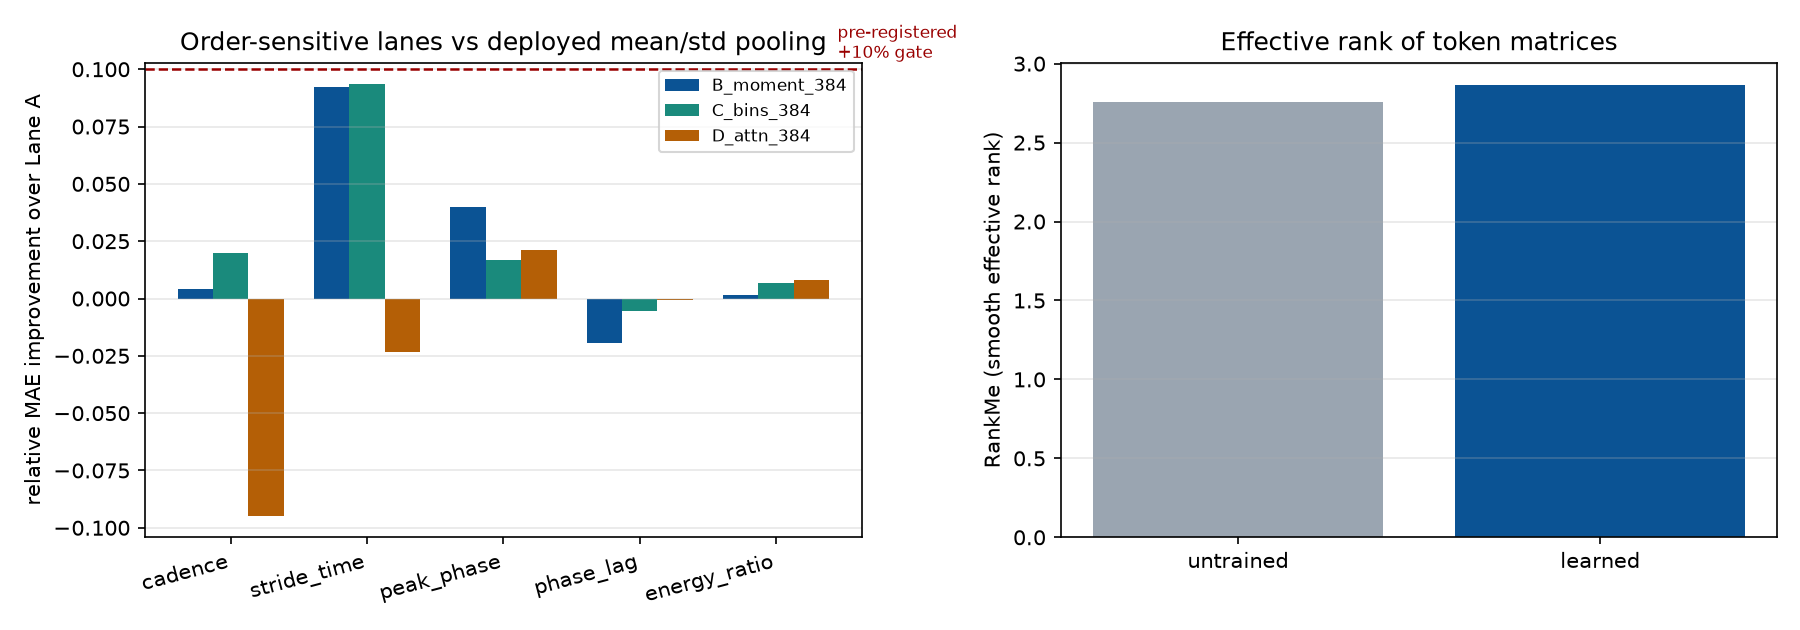

In [17]:
from IPython.display import Image, display

display(Image(filename="work/artifacts/real/temporal_readout_summary.png"))

## What to read next

* `08_normal_anchor_drift_and_consolidation.ipynb` — turns the measured normal-anchor drift
  (cosine 0.954 → 0.594) into the primary paper's core experiment with a consolidation repair.
* `09_predictive_surprise_world_model.ipynb` — flips the mask axis from spatial infilling to
  *future forecasting* and scores predictive surprise per condition (zero training).
* `docs/neurips-brain-body.md` — the full roadmap, claim discipline, and the 72-hour plan.

**Research use only.** No diagnostic or clinical claims are made or implied.
